IEEE-CIS Fraud Detection
https://www.kaggle.com/competitions/ieee-fraud-detection

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
# import kagglehub
import matplotlib.pyplot as plt
import os
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from sklearn.cluster import KMeans
# from yellowbrick.cluster import KElbowVisualizer
# from sklearn.cluster import AgglomerativeClustering, DBSCAN
# from sklearn.decomposition import PCA
# from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')

path = '/content/drive/MyDrive/Semester 2/Proyek Penelitian Terapan/script/dataset/'

# EDA

In [3]:
train_transaction = pd.read_csv(path+'train_transaction.csv')
train_identity = pd.read_csv(path+'train_identity.csv')
test_transaction = pd.read_csv(path+'test_transaction.csv')
test_identity = pd.read_csv(path+'test_identity.csv')

print(train_transaction.shape)
print(train_identity.shape)
# print(test_transaction.shape)
# print(test_identity.shape)

(590540, 394)
(144233, 41)


In [4]:
df = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')
print(f"train shape: {df.shape}")
df_test = pd.merge(test_transaction, test_identity, on='TransactionID', how='left')
print(f"test shape: {df_test.shape}")

train shape: (590540, 434)
test shape: (506691, 433)


In [5]:
print("train_transaction : ", train_transaction.shape)
print("train_identity : ", train_identity.shape)
print("test_transaction : ", test_transaction.shape)
print("test_identity : ", test_identity.shape)
print("merged train: ", df.shape)
print("merged test: ", df_test.shape)

train_transaction :  (590540, 394)
train_identity :  (144233, 41)
test_transaction :  (506691, 393)
test_identity :  (141907, 41)
merged train:  (590540, 434)
merged test:  (506691, 433)


In [6]:
# prompt: hitung total baris nan data dari df. print juga total baris datanya
print("--- Data train ---")
print(f'Total rows with NaN values: {df.isna().any(axis=1).sum()}')
print(f'Total rows in the DataFrame: {len(df)}')
print("--- Data test ---")
print(f'Total rows with NaN values: {df_test.isna().any(axis=1).sum()}')
print(f'Total rows in the DataFrame: {len(df_test)}')

--- Data train ---
Total rows with NaN values: 590540
Total rows in the DataFrame: 590540
--- Data test ---
Total rows with NaN values: 506691
Total rows in the DataFrame: 506691


## Cek null per kolom

In [7]:
null_df = []
for col in df.columns:
  # print(col,":", len(df[col].unique()),"nan", df[col].isnull().sum())
  null_df.append(({
      "colname":col,
      "unique val": len(df[col].unique()),
      "null val": df[col].isnull().sum(),
      "percentage null": round(df[col].isnull().sum()/len(df),4),
      "dtype": df[col].dtype
  }))

null_df = pd.DataFrame(null_df)
print("data train")
null_df.sort_values(by='percentage null', ascending=False).head(10)


data train


,colname,unique val,null val,percentage null,dtype
417,id_24,13,585793,0.9920,float64
414,id_21,491,585381,0.9913,float64
400,id_07,85,585385,0.9913,float64
418,id_25,342,585408,0.9913,float64
419,id_26,96,585377,0.9913,float64
401,id_08,95,585385,0.9913,float64
420,id_27,3,585371,0.9912,object
416,id_23,4,585371,0.9912,object
415,id_22,26,585371,0.9912,float64
14,dist2,1752,552913,0.9363,float64


In [8]:
df['dist2'].unique()

array([  nan,   30.,   98., ..., 1467., 1172., 2296.])

In [9]:
null_df_test = []
for col in df_test.columns:
  # print(col,":", len(df[col].unique()),"nan", df[col].isnull().sum())
  null_df_test.append(({
      "colname":col,
      "unique val": len(df_test[col].unique()),
      "null val": df_test[col].isnull().sum(),
      "percentage null": round(df_test[col].isnull().sum()/len(df_test),4),
      "dtype": df_test[col].dtype
  }))

null_df_test = pd.DataFrame(null_df_test)
print("data test")
null_df_test.sort_values(by='percentage null', ascending=False).head(10)

data test


,colname,unique val,null val,percentage null,dtype
416,id-24,16,501951,0.9906,float64
417,id-25,310,501652,0.9901,float64
413,id-21,444,501632,0.9900,float64
414,id-22,27,501629,0.9900,float64
400,id-08,91,501632,0.9900,float64
415,id-23,4,501629,0.9900,object
419,id-27,3,501629,0.9900,object
418,id-26,95,501644,0.9900,float64
399,id-07,82,501632,0.9900,float64
13,dist2,1815,470255,0.9281,float64


## Cek data duplikat

In [10]:
print(len(df[df.duplicated(subset=['TransactionID'])]))

0


In [11]:
print("--- Data train ---")
print(f"columns with 0 null value :{len(null_df[null_df['null val'] == 0])}")
print(f"columns with null value >0 and <2% :{len(null_df[(null_df['percentage null'] > 0) & (null_df['percentage null'] < 0.02)])}")
print(f"columns with null value >2% and <5% :{len(null_df[(null_df['percentage null'] > 0.02) & (null_df['percentage null'] < 0.05)])}")
print(f"columns with null value >5% and <10% :{len(null_df[(null_df['percentage null'] > 0.05) & (null_df['percentage null'] < 0.1)])}")
print(f"columns with null value >10% and <20% :{len(null_df[(null_df['percentage null'] > 0.1) & (null_df['percentage null'] < 0.2)])}")
print(f"columns with null value >20% and <50% :{len(null_df[(null_df['percentage null'] > 0.2) & (null_df['percentage null'] < 0.5)])}")
print(f"columns with null value >50% :{len(null_df[null_df['percentage null'] > 0.5])}")

--- Data train ---
columns with 0 null value :20
columns with null value >0 and <2% :60
columns with null value >2% and <5% :0
columns with null value >5% and <10% :0
columns with null value >10% and <20% :70
columns with null value >20% and <50% :38
columns with null value >50% :214


In [12]:
print("--- Data test ---")
print(f"columns with 0 null value :{len(null_df_test[null_df_test['null val'] == 0])}")
print(f"columns with null value >0 and < 2% :{len(null_df_test[(null_df_test['percentage null'] > 0) & (null_df_test['percentage null'] < 0.02)])}")
print(f"columns with null value >2% and <5% :{len(null_df_test[(null_df_test['percentage null'] > 0.02) & (null_df_test['percentage null'] < 0.05)])}")
print(f"columns with null value >5% and <10% :{len(null_df_test[(null_df_test['percentage null'] > 0.05) & (null_df_test['percentage null'] < 0.1)])}")
print(f"columns with null value >10% and <20% :{len(null_df_test[(null_df_test['percentage null'] > 0.1) & (null_df_test['percentage null'] < 0.2)])}")
print(f"columns with null value >20% and <50% :{len(null_df_test[(null_df_test['percentage null'] > 0.2) & (null_df_test['percentage null'] < 0.5)])}")
print(f"columns with null value >50% :{len(null_df_test[null_df_test['percentage null'] > 0.5])}")

--- Data test ---
columns with 0 null value :48
columns with null value >0 and < 2% :18
columns with null value >2% and <5% :67
columns with null value >5% and <10% :0
columns with null value >10% and <20% :22
columns with null value >20% and <50% :23
columns with null value >50% :210


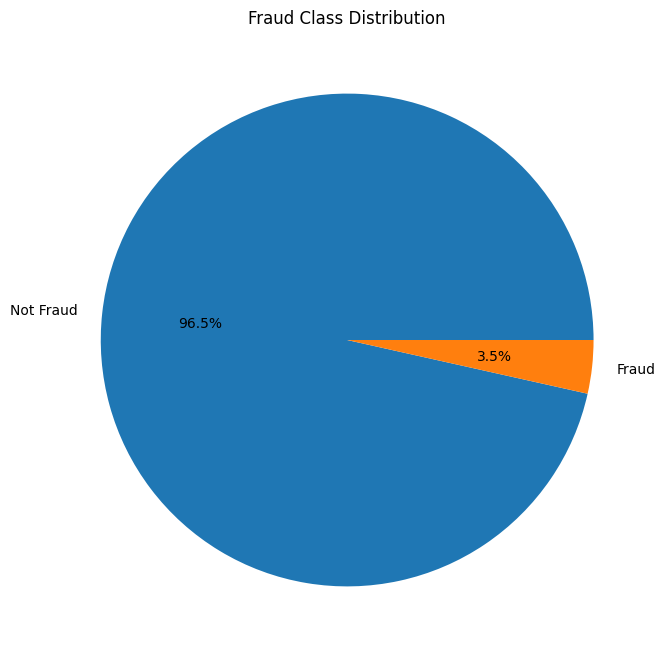

In [13]:
category_counts = df['isFraud'].value_counts()

# labels=[f'{cat} ({count})' for cat, count in zip(category_counts.index, category_counts)]
plt.figure(figsize=(8, 8))
plt.pie(category_counts, labels=[f'Fraud' if cat == 1 else 'Not Fraud' for cat in category_counts.index], autopct='%1.1f%%')
plt.title('Fraud Class Distribution')
plt.show()

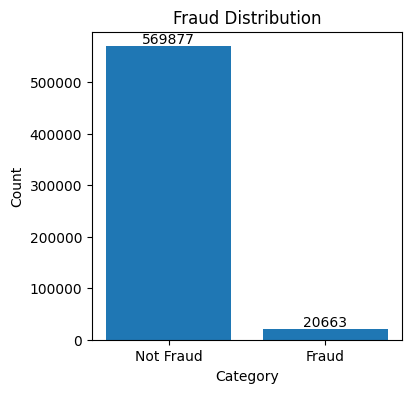

In [14]:
# prompt: buat bar chart dari fraud di atas, berikan jumlah aslinya

import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame and 'isFraud' is the column with fraud data.
fraud_counts = df['isFraud'].value_counts()

plt.figure(figsize=(4, 4))
plt.bar(fraud_counts.index, fraud_counts.values)
plt.xticks(fraud_counts.index, ['Not Fraud', 'Fraud'])
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Fraud Distribution')

# Add the actual counts on top of each bar
for i, v in enumerate(fraud_counts.values):
    plt.text(i, v + 6000, str(v), ha='center')  # Adjust 500 as needed for vertical spacing

plt.show()


In [15]:
null_df[null_df['unique val'] < 10]

,colname,unique val,null val,percentage null,dtype
1,isFraud,2,0,0.0000,int64
4,ProductCD,5,0,0.0000,object
8,card4,5,1577,0.0027,object
10,card6,5,1571,0.0027,object
46,M1,3,271100,0.4591,object
...,...,...,...,...,...
428,id_35,3,449555,0.7613,object
429,id_36,3,449555,0.7613,object
430,id_37,3,449555,0.7613,object
431,id_38,3,449555,0.7613,object


In [16]:
df['V10'].unique()

array([ 0., nan,  1.,  2.,  3.,  4.])

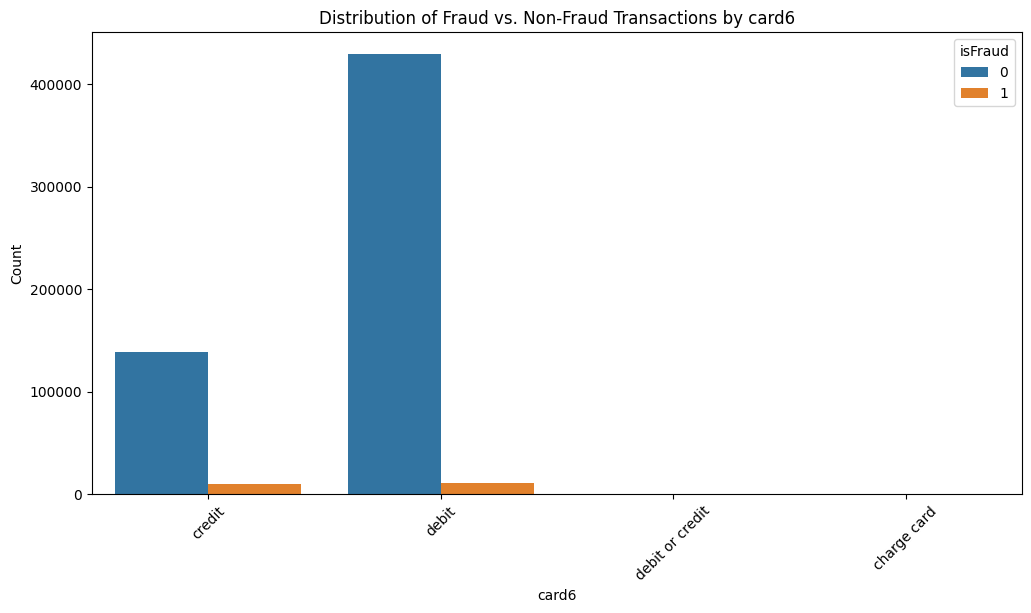

In [17]:
# prompt: buat distribusi perbandingan fraud dan tidak terhadap card6

import matplotlib.pyplot as plt
# Assuming 'df' is your DataFrame and it's already loaded as shown in your provided code.

plt.figure(figsize=(12, 6))
sns.countplot(x='card6', hue='isFraud', data=df)
plt.title('Distribution of Fraud vs. Non-Fraud Transactions by card6')
plt.xlabel('card6')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


-0.4 0
0.6000000000000001 0
5.551115123125783e-17 0
1.0000000000000002 0
0 0
0 0


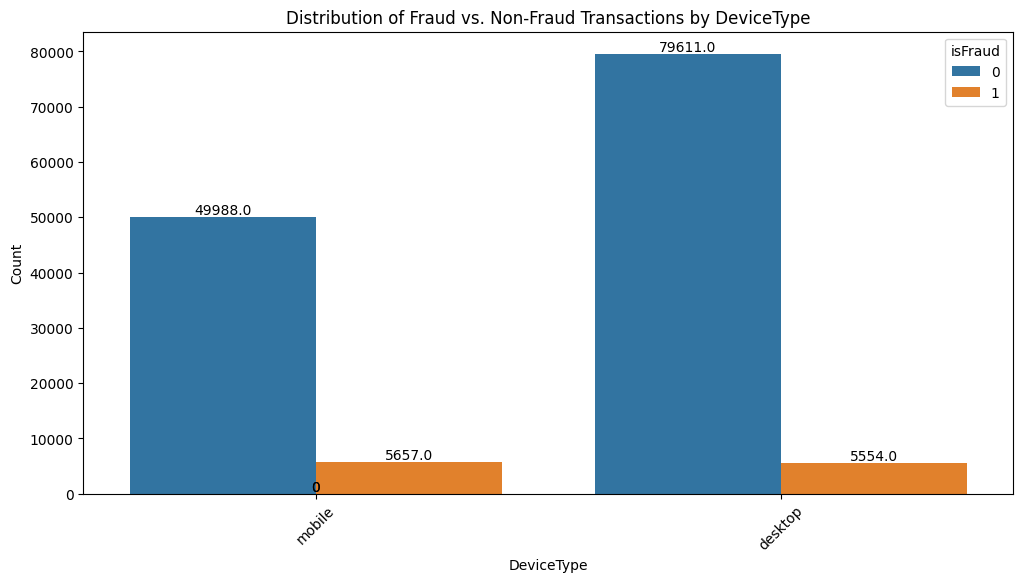

In [18]:
# prompt: buat distribusi perbandingan fraud dan tidak terhadap DeviceType. berikan juga nilai aslinya di dalam chart

import matplotlib.pyplot as plt
# Assuming 'df' is your DataFrame and it's already loaded as shown in your provided code.

plt.figure(figsize=(12, 6))
sns.countplot(x='DeviceType', hue='isFraud', data=df)
plt.title('Distribution of Fraud vs. Non-Fraud Transactions by DeviceType')
plt.xlabel('DeviceType')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Add the actual counts on top of each bar
counter = 0
for p in plt.gca().patches:
      height = p.get_height()
      x, y = p.get_xy()
      print(x,y)
      plt.text(x + p.get_width() / 2, height + 500, height, ha='center')  # Adjust 500 as needed for vertical spacing

plt.show()


In [19]:
df['TransactionDT'].head(10)

,TransactionDT
0,86400
1,86401
2,86469
3,86499
4,86506
5,86510
6,86522
7,86529
8,86535
9,86536


In [20]:
# prompt: buat kolom baru dari df['TransactionDT'] yang merupakan timedelta kemudian ubah ke dalam timestamp dan ditaruh di kolom baru

import pandas as pd

# Assuming 'df' is your DataFrame and 'TransactionDT' is the column with timedelta values.
# Convert 'TransactionDT' to timedelta objects if it's not already.  The code assumes it *is* already a numeric representation of seconds.
# If it's a string or another format, you might need to adjust this conversion.
df['tr_timestamp'] = pd.to_timedelta(df['TransactionDT'], unit='s')

# Calculate the timestamp from a reference point.  This assumes the TransactionDT is relative to some point in time. You'll need to replace this with the *actual* reference time.
reference_timestamp = pd.Timestamp('2017-12-01')  # Example reference point; replace this
df['tr_timestamp'] = reference_timestamp + df['tr_timestamp']

# Display the updated dataframe (Optional)
df[['TransactionDT', 'tr_timestamp']].head()


,TransactionDT,tr_timestamp
0,86400,2017-12-02 00:00:00
1,86401,2017-12-02 00:00:01
2,86469,2017-12-02 00:01:09
3,86499,2017-12-02 00:01:39
4,86506,2017-12-02 00:01:46


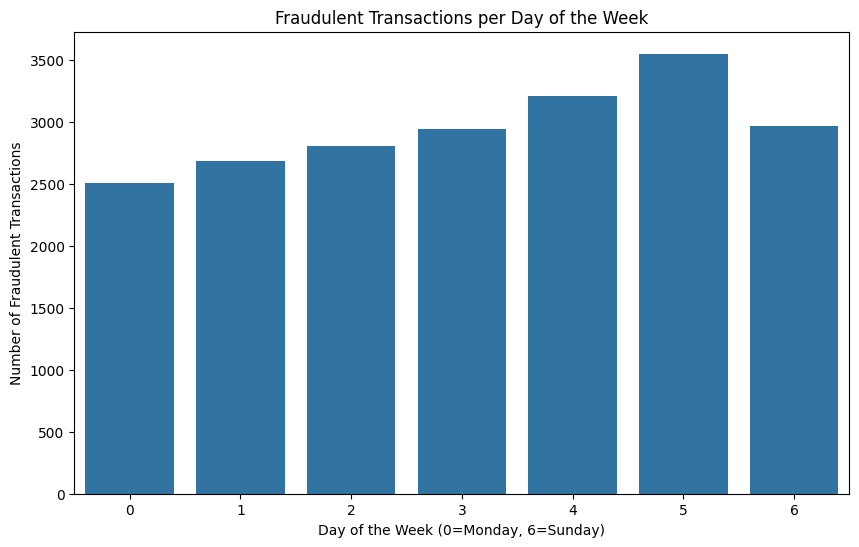

In [21]:
# prompt: buat chart untuk melihat isfraud = 1 dalam satu minggu untuk melihat hari apa dengan jumlah fraud terbanyak

import matplotlib.pyplot as plt
# Assuming 'df' is your DataFrame and 'tr_timestamp' is the datetime column.
# Ensure 'tr_timestamp' is a datetime column (as done in the previous code).

# Extract day of the week
df['day_of_week'] = df['tr_timestamp'].dt.dayofweek

# Group by day of the week and count fraudulent transactions
fraud_by_day = df[df['isFraud'] == 1].groupby('day_of_week')['isFraud'].count()

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x=fraud_by_day.index, y=fraud_by_day.values)
plt.title('Fraudulent Transactions per Day of the Week')
plt.xlabel('Day of the Week (0=Monday, 6=Sunday)')
plt.ylabel('Number of Fraudulent Transactions')
plt.xticks(range(7))  # Ensure all days are shown on the x-axis
plt.show()


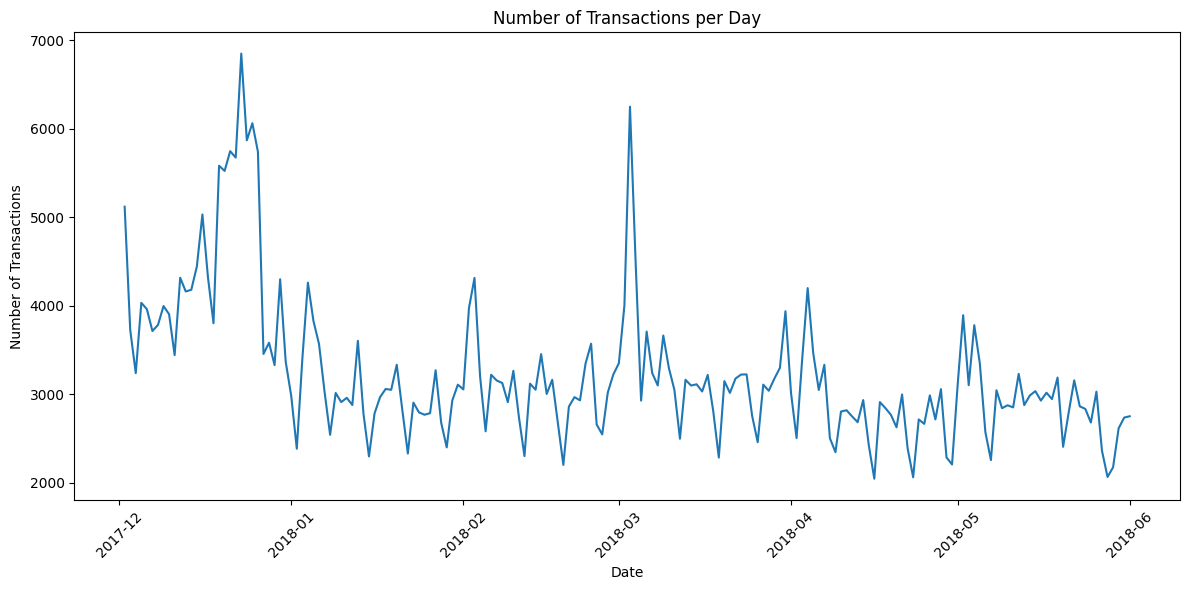

In [22]:
# prompt: buat chart untuk melihat jumlah transaksi per hari

import matplotlib.pyplot as plt
# Assuming 'df' is your DataFrame and 'tr_timestamp' is the datetime column.
# Ensure 'tr_timestamp' is a datetime column (as done in the previous code).

# Extract the date
df['transaction_date'] = df['tr_timestamp'].dt.date

# Group by date and count transactions
transactions_per_day = df.groupby('transaction_date')['TransactionID'].count()

# Create the line plot
plt.figure(figsize=(12, 6))
plt.plot(transactions_per_day.index, transactions_per_day.values)
plt.title('Number of Transactions per Day')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()


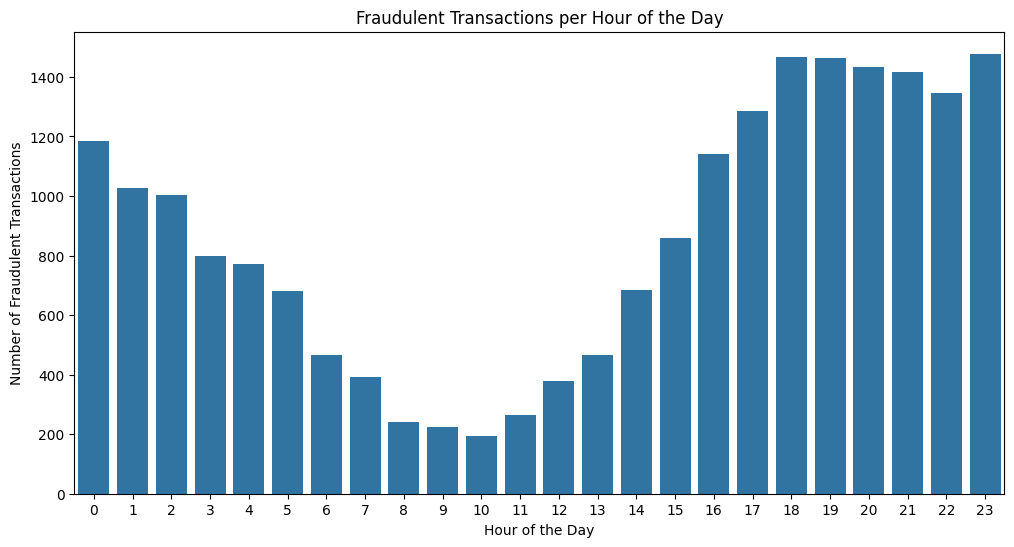

In [23]:
# prompt: buat juga untuk per jamnya

import matplotlib.pyplot as plt
# Assuming 'df' is your DataFrame and 'tr_timestamp' is the datetime column.
# Ensure 'tr_timestamp' is a datetime column (as done in the previous code).

# Extract the hour of the day
df['hour_of_day'] = df['tr_timestamp'].dt.hour

# Group by hour of the day and count fraudulent transactions
fraud_by_hour = df[df['isFraud'] == 1].groupby('hour_of_day')['isFraud'].count()

# Create the bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x=fraud_by_hour.index, y=fraud_by_hour.values)
plt.title('Fraudulent Transactions per Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Fraudulent Transactions')
plt.xticks(range(24))  # Ensure all hours are shown on the x-axis
plt.show()


In [24]:
# prompt: buat juga untuk per bulan. ganti dengan 0 jika di bulan tersebut tidak terjadi fraud

import pandas as pd
import matplotlib.pyplot as plt
# Assuming 'df' is your DataFrame and 'tr_timestamp' is the datetime column.
# Ensure 'tr_timestamp' is a datetime column (as done in the previous code).

# Extract the month
df['month'] = df['tr_timestamp'].dt.month

# Group by month and count fraudulent transactions
fraud_by_month = df.groupby('month')['isFraud'].sum()

# Create a complete monthly index (1-12)
monthly_index = pd.Index(range(1, 13), name='month')

# Reindex the fraud_by_month series to include all months, filling missing values with 0
fraud_by_month = fraud_by_month.reindex(monthly_index, fill_value=0)

# Add the actual counts on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 10),
                textcoords='offset points')
# Create the bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x=fraud_by_month.index, y=fraud_by_month.values)
plt.title('Fraudulent Transactions per Month')
plt.xlabel('Month')
plt.ylabel('Number of Fraudulent Transactions')
plt.show()


NameError: name 'ax' is not defined

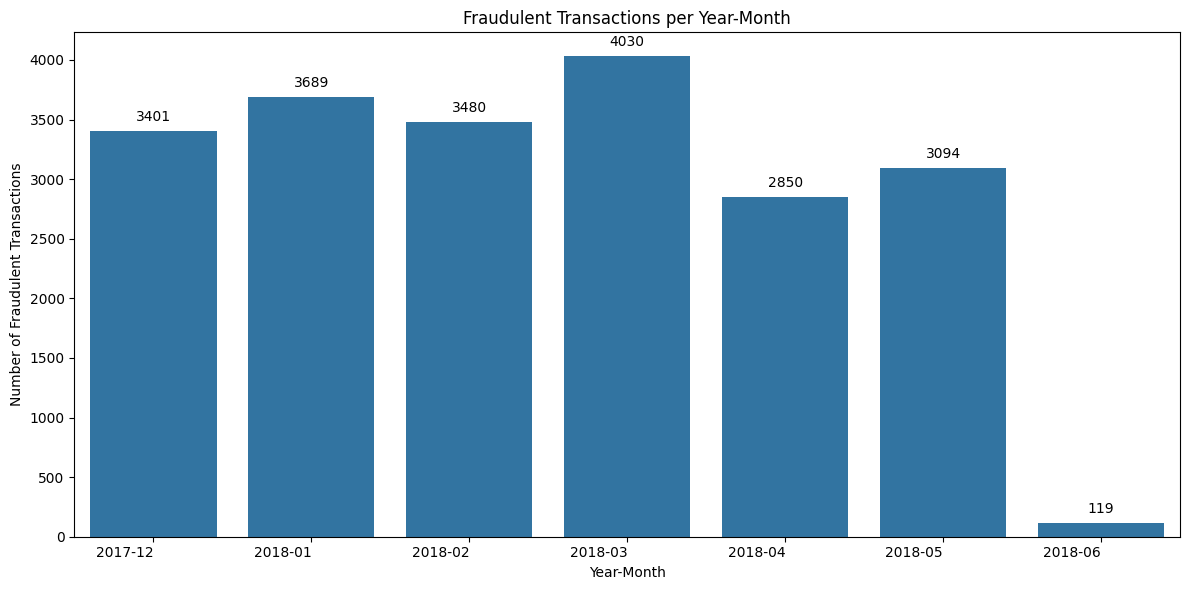

In [25]:
# prompt: buat chart di atas persis dan tambahkan angka di atas bar. ubah pengelompokkan dengan berdasarkan bulan dan tahun

import matplotlib.pyplot as plt
# Assuming 'df' is your DataFrame and 'tr_timestamp' is the datetime column.
# Ensure 'tr_timestamp' is a datetime column (as done in the previous code).

# Extract the year and month
df['year'] = df['tr_timestamp'].dt.year
df['month'] = df['tr_timestamp'].dt.month

# Combine year and month into a single column
df['year_month'] = df['year'].astype(str) + '-' + df['month'].astype(str).str.zfill(2)

# Group by year_month and count fraudulent transactions
fraud_by_year_month = df.groupby('year_month')['isFraud'].sum()

# Create the bar plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=fraud_by_year_month.index, y=fraud_by_year_month.values)
plt.title('Fraudulent Transactions per Year-Month')
plt.xlabel('Year-Month')
plt.ylabel('Number of Fraudulent Transactions')
plt.xticks( ha='right')  # Rotate x-axis labels for better readability

# Add the actual counts on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 10),
                textcoords='offset points')

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()


In [26]:
# prompt: berikan tanggal paling awal dan paling akhir

# Assuming 'df' is your DataFrame and 'tr_timestamp' is the datetime column.
# Ensure 'tr_timestamp' is a datetime column (as done in the previous code).

# Find the earliest and latest dates
earliest_date = df['tr_timestamp'].min()
latest_date = df['tr_timestamp'].max()

print(f"Earliest Date: {earliest_date}")
print(f"Latest Date: {latest_date}")


Earliest Date: 2017-12-02 00:00:00
Latest Date: 2018-06-01 23:58:51


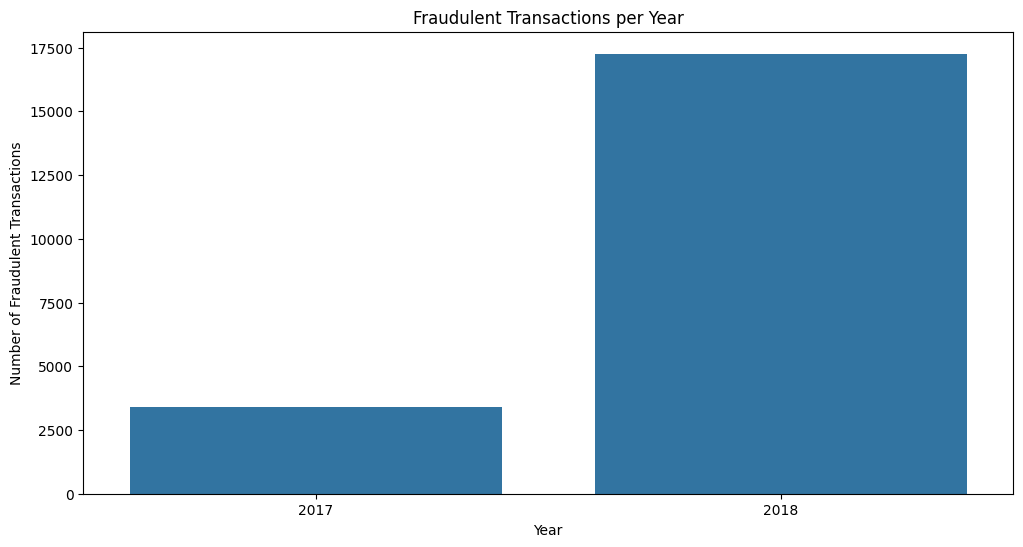

In [27]:
# prompt: buat dengan per tahun

import matplotlib.pyplot as plt
# Assuming 'df' is your DataFrame and 'tr_timestamp' is the datetime column.
# Ensure 'tr_timestamp' is a datetime column (as done in the previous code).

# Extract the year
df['year'] = df['tr_timestamp'].dt.year

# Group by year and count fraudulent transactions
fraud_by_year = df.groupby('year')['isFraud'].sum()

# Create the bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x=fraud_by_year.index, y=fraud_by_year.values)
plt.title('Fraudulent Transactions per Year')
plt.xlabel('Year')
plt.ylabel('Number of Fraudulent Transactions')
plt.show()


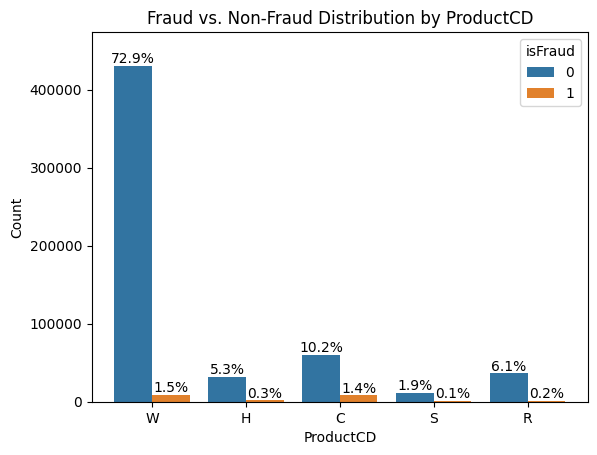

In [28]:
# prompt: buat distribusi perbandingan fraud dan tidak terhadap ProductCD

# import matplotlib.pyplot as plt
# # Assuming 'df' is your DataFrame and 'ProductCD' and 'isFraud' are the relevant columns.
# plt.figure(figsize=(10, 6))
# sns.countplot(x='ProductCD', hue='isFraud', data=df)

ax = sns.countplot(x='ProductCD', hue='isFraud', data = df)

plt.margins(0.05, 0.1)

counter = 0
for p in ax.patches:
    x=p.get_bbox().get_points()[:,0]
    y=p.get_bbox().get_points()[1,1]
    if counter < 10:
      ax.annotate('{:.1f}%'.format(100.*y/len(df)), (x.mean(), y),
            ha='center', va='bottom')
    counter += 1
plt.title('Fraud vs. Non-Fraud Distribution by ProductCD')
plt.xlabel('ProductCD')
plt.ylabel('Count')
plt.show()

In [29]:
print(len(ax.patches))

12


# Preprocessing

## Rename column

In [30]:
df_test.columns = df_test.columns.str.replace('^id-', 'id_', regex=True)

In [31]:
# prompt: tampilkan kolom df_test yang berawalan id

df_test.filter(regex='^id').head(1)


,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,...,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
print(categorical_cols)

Index(['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1',
       'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15',
       'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33',
       'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo',
       'transaction_date', 'year_month'],
      dtype='object')


In [33]:
# prompt: untuk setiap kolom kategorikal di df, ubah NaN data menjadi kata null

for col in categorical_cols:
    df[col] = df[col].fillna('null')
for col in categorical_cols:
    df_test[col] = df_test[col].fillna('null')

KeyError: 'transaction_date'

In [34]:
# prompt: hapus dari memori untuk train_identity, train_transaction, test_identity, dan test_transaction

import gc

del train_identity
del train_transaction
del test_identity
del test_transaction

gc.collect()


16802

In [ ]:
# prompt: untuk setiap kolom numerik di df dan df_test, ubah nan data menjadi -999

for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(-999)

for col in df_test.select_dtypes(include=np.number).columns:
    df_test[col] = df_test[col].fillna(-999)


In [ ]:
# df.to_csv(path+'train_preprocessing.csv', index=False)
# # df_test.to_csv('df_test.csv', index=False)

In [ ]:
# df_test.to_csv(path+'test_preprocessing.csv', index=False)

In [ ]:
df_no_null = df.dropna()
df_no_null.shape

In [ ]:
# prompt: delete column yang memiliki null value di atas 50%

# Delete columns with more than 50% null values
print("before drop column: ", df.shape)
threshold = 0.50
columns_to_delete = null_df[null_df['percentage null'] > threshold]['colname'].tolist()
df_no_null = df.drop(columns=columns_to_delete)

df_no_null = df_no_null.dropna()
print("after drop column: ", df_no_null.shape)


In [ ]:
# prompt: encode dengan mengubah text menjadi angka untuk df_no_null. buat correlation matrix terhadap isFraud dari df_no_null. buat chart korelasinya hanya 20 fitur terbaik

import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Select columns with object or category data types
categorical_cols = df_no_null.select_dtypes(include=['object', 'category']).columns

# Create a LabelEncoder object
le = LabelEncoder()

# Iterate over the selected columns and apply label encoding
for col in categorical_cols:
    df_no_null[col] = le.fit_transform(df_no_null[col])

# Calculate the correlation matrix
correlation_matrix = df_no_null.corr()

# Get the correlation with 'isFraud'
isfraud_correlation = correlation_matrix['isFraud'].drop('isFraud')

# Sort by absolute correlation value to get the top 20 features
top_20_features = isfraud_correlation.abs().sort_values(ascending=False).head(20)

# Plot the correlations
plt.figure(figsize=(12, 6))
sns.barplot(x=top_20_features.values, y=top_20_features.index)
plt.title('Top 20 Feature Correlations with isFraud')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Feature')
plt.show()


In [ ]:
print("before drop column: ", df_test.shape)
threshold = 0.50
columns_to_delete = null_df_test[null_df_test['percentage null'] > threshold]['colname'].tolist()
df_test = df_test.drop(columns=columns_to_delete)

print("after drop column: ", df_test.shape)


In [ ]:
# prompt: buat pie chart dari df antara jumlah baris yang tidak memiliki null dengan yang memiliki null

import matplotlib.pyplot as plt
# Assuming 'df' is your DataFrame from the previous code

# Calculate the number of rows with and without null values
rows_without_nulls = len(df.dropna())
rows_with_nulls = len(df) - rows_without_nulls

# Create the pie chart
labels = [f'Without Null Values ({rows_without_nulls})', f'With Null Values ({rows_with_nulls})']
sizes = [rows_without_nulls, rows_with_nulls]
colors = ['lightblue', 'lightcoral']

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Rows with and without Null Values')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


In [1]:
# Calculate the number of NaN values in each row of train_identity
nan_counts = train_transaction.isnull().sum(axis=1)

# Find the index of the row with the fewest NaN values
min_nan_index = nan_counts.idxmin()

# Print the row with the fewest NaN values
train_transaction.loc[[min_nan_index]].T


NameError: name 'train_transaction' is not defined

In [ ]:
# prompt: show df isFraud = 1
df[df['isFraud'] == 1]

In [ ]:
print(len(df.dropna()))

In [ ]:
# prompt: buat agar kolom dan jumlah df_test persis seperti df

import numpy as np
# Align df_test columns with df, adding missing columns with NaN values
for col in df.columns:
    if col not in df_test.columns:
        df_test[col] = np.nan

# Align df_test's column order with df
df_test = df_test[df.columns]

df_test.shape


In [ ]:
# prompt: lihat unique value di atas 2 dan di bawah 5

# Assuming 'null_df' DataFrame is already created as in the provided code.

# Filter unique values between 2 and 5 (exclusive)
# filtered_df = null_df[(null_df['unique val'] > 50)]
filtered_df = null_df[(null_df['unique val'] > 1) & (null_df['unique val'] < 5)]
# Display the filtered DataFrame
len(filtered_df)


In [ ]:
filtered_df

In [ ]:
df['D10'].unique()

In [ ]:
for col in filtered_df['column name']:

  print(col,":", df[col].unique(),)

In [ ]:
# prompt: tunjukkan data yang memiliki isFraud null

# Display rows where 'isFraud' is null
print(len(train_transaction[train_transaction['isFraud'].isnull()]))
print(len(df[df['isFraud'].isnull()]))


In [ ]:
df['isFraud'] = df['isFraud'].fillna(0)
df.loc[df['isFraud'].isnull()]

In [ ]:
# prompt: cek train_transaction dengan TransactionID = 3011015

# Check for TransactionID = 3011015 in train_transaction
transaction_ = train_transaction[train_transaction['TransactionID'] == 3011015]

# Display the row if found, otherwise print a message
transaction_


In [ ]:
null_df

In [ ]:
# Introduce some null values randomly
# df = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')
for col in df.columns:
    df.loc[np.random.choice(df.index, 5, replace=False), col] = np.nan

# Step 2: Prepare to count null values and get data types
null_info = []
len_df = len(df)
# Step 3: Loop through each column to count null values and get data types
counter = 1
for col in df.columns:
    null_count = df[col].isnull().sum()  # Count null values
    dtype = df[col].dtype  # Get data type
    percentage_null = round(null_count/len_df,4)
    # print(f'{counter}.{col}, dtype:{dtype}, null val:{null_count}, percentage:{percentage_null}, unique val:{df[col].nunique()}')
    counter += 1
    # if percentage_null <= 0.1:
    null_info.append((col, null_count, dtype, percentage_null))  # Append to the list

# Step 4: Create a DataFrame to display the results
null_df = pd.DataFrame(null_info, columns=['column name', 'null count', 'data type', 'percentage null'])

# # Filter to show only columns with null values
# null_df = null_df[null_df['Null Count'] > 0]

# # Display the DataFrame with null counts and data types
null_df

In [ ]:
len(df)

In [ ]:
null_df.sort_values(by='percentage null', ascending=False)

In [ ]:
65711/len(df)

In [ ]:
category_counts = df['isFraud'].value_counts()

# Langkah 3: Buat pie chart
plt.figure(figsize=(8, 8))
plt.pie(category_counts, labels=[f'{cat} ({count})' for cat, count in zip(category_counts.index, category_counts)], autopct='%1.1f%%')
plt.title('Category Distribution')
plt.show()

In [ ]:
df['isFraud'].nunique()